# Ballistic Expansion Imaging Checks

Three sanity checks that validate the imaging pipeline using freefall-only
sequences where expected behaviour is analytically known:

1. **Static atom** — single atom at rest; every frame must be an identical
   Gaussian blob (the fixed blur is independent of drop time).
2. **Drifting atom** — single atom with *v*ᶻ and *v*ˣ; the blob must
   move linearly in z and x across the filmstrip.
3. **Thermal cloud at 1 µK** — 200-atom ensemble with Gaussian position
   spread (σ = 100 µm) and Maxwell–Boltzmann velocities; the cloud must
   expand ballistically over 10 ms.

In [1]:
%matplotlib inline
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from scipy import constants
from tqdm import tqdm

import lmt_sim.lmt_simulation as sim
import lmt_sim.version_info as vs
from lmt_sim.lmt_simulation import make_atom_states
from lmt_sim.lmt_sequence import Freefall, iter_pulse_sequence_in_borde_representation
from lmt_sim.imaging import (
    collect_branches,
    stack_atoms,
    render,
    pixel_grid,
    SINGLE_ATOM_WAVEPACKET_SIGMA_M,
)

print(f"Wavepacket blur: {SINGLE_ATOM_WAVEPACKET_SIGMA_M*1e6:.0f} µm")
print(f"Recoil velocity: {sim.RECOIL_VELOCITY*1e3:.4f} mm/s")

Wavepacket blur: 10 µm
Recoil velocity: 6.5710 mm/s


In [2]:
# Shared sequence: 10 × 1 ms freefalls
N_STEPS = 10
DT = 1e-3
SEQUENCE = [Freefall(duration=DT, label=f"t={i + 1}ms") for i in range(N_STEPS)]
LABELS = ["t=0 ms"] + [f"t={i + 1} ms" for i in range(N_STEPS)]


def collect_snapshots(atoms, sequence, desc="Atoms"):
    """Snapshot ground/excited branches after every sequence event.

    atoms: list of dicts with optional keys px/py/pz/vx/vy/vz (default 0).
    """
    n_snap = len(sequence) + 1
    snap_g = [[] for _ in range(n_snap)]
    snap_e = [[] for _ in range(n_snap)]

    for atom_id, atom in enumerate(tqdm(atoms, desc=desc, leave=False)):
        px = atom.get("px", 0.0);  py = atom.get("py", 0.0);  pz = atom.get("pz", 0.0)
        vx = atom.get("vx", 0.0);  vy = atom.get("vy", 0.0);  vz = atom.get("vz", 0.0)

        initial = make_atom_states(
            position_x=px, position_y=py, position_z=pz,
            velocity_x=vx, velocity_y=vy, initial_velocity_z=vz,
        )
        # At t=0 with m=0 the Bordé frame equals the lab frame, so the
        # initial state can be passed directly to the Bordé iterator.
        for i, (state, detuning_hz, t) in enumerate(
            iter_pulse_sequence_in_borde_representation(
                initial, sequence, initial_velocity_z=vz, discard_threshold=1e-9,
            )
        ):
            lab_state = sim.transform_state_vector(
                state,
                omega_laser=2 * np.pi * (sim.TRANSITION_FREQUENCY + detuning_hz),
                t=t, z=0.0, vz=vz, inverse=True,
            )
            g, e = collect_branches(lab_state)
            if len(g): snap_g[i].append(g)
            if len(e): snap_e[i].append(e)

    return [stack_atoms(s) for s in snap_g], [stack_atoms(s) for s in snap_e]


def render_filmstrip(snaps, labels, title, *, channel="ground",
                     n_x=30, n_z=60, panel_width=2.3, panel_height=3.8,
                     x_pad_min=30e-6, z_pad_min=30e-6, common_scale=True):
    """Single-row filmstrip from pre-collected branch snapshots."""
    non_empty = [s for s in snaps if len(s)]
    x_edges, z_edges = pixel_grid(non_empty, n_x=n_x, n_z=n_z,
                                  x_pad_min=x_pad_min, z_pad_min=z_pad_min)
    imgs = [render(s, x_edges, z_edges) for s in snaps]
    global_max = max(img.max() for img in imgs) or 1.0
    extent = [1e6*x_edges[0], 1e6*x_edges[-1], 1e6*z_edges[0], 1e6*z_edges[-1]]

    n_panels = len(snaps)
    fig, axes = plt.subplots(1, n_panels,
                             figsize=(panel_width * n_panels, panel_height),
                             sharex=True, sharey=True, constrained_layout=True)
    if n_panels == 1:
        axes = [axes]

    for col, (ax, img, label) in enumerate(zip(axes, imgs, labels)):
        vmax = global_max if common_scale else (img.max() or 1.0)
        ax.imshow(img, origin="lower", aspect="auto", extent=extent,
                  cmap="magma", vmin=0, vmax=vmax)
        ax.set_title(label, fontsize=8)
        if col == 0:
            ax.set_ylabel(f"{channel}\n" + r"$z$ ($\mu$m)", fontsize=8)
        ax.set_xlabel(r"$x$ ($\mu$m)", fontsize=7)
        ax.text(0.03, 0.97, f"pk={img.max():.1f}\nΣ={img.sum():.1f}",
                transform=ax.transAxes, fontsize=6, color="white", va="top")

    fig.suptitle(title, fontsize=9)
    vs.tag_plot(small=True)
    return fig

## Check 1 — Static atom

A single atom at rest at the origin.  All 11 panels must show an identical
Gaussian blob.  The fixed `SINGLE_ATOM_WAVEPACKET_SIGMA_M` blur does not
depend on free-fall time, so nothing should change.

Check 1:   0%|          | 0/1 [00:00<?, ?it/s]

Max frame-to-frame pixel difference: 6.88e-22  (expect ~0)


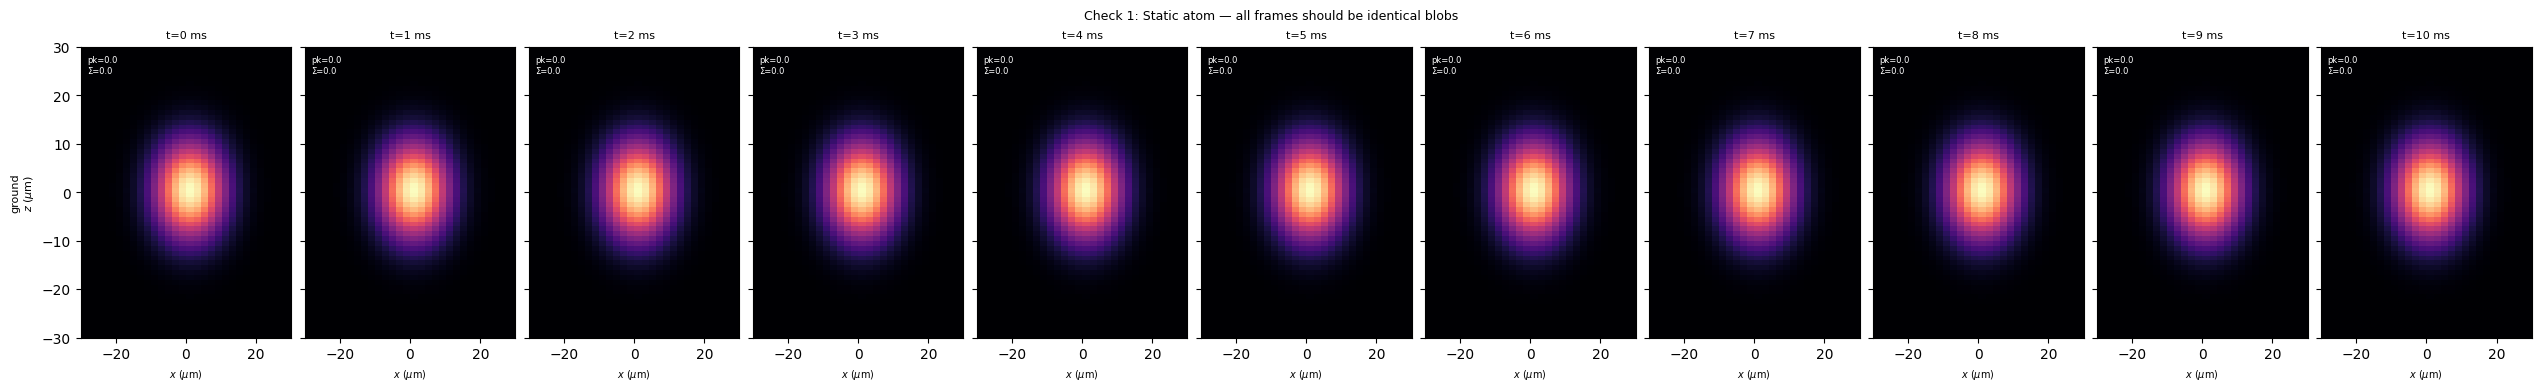

In [3]:
atoms_1 = [{"px": 0.0, "pz": 0.0, "vx": 0.0, "vz": 0.0}]
snap_g1, _ = collect_snapshots(atoms_1, SEQUENCE, desc="Check 1")

# Quantitative: frame-to-frame pixel difference should be ~0
ref_grid = pixel_grid([snap_g1[0]], n_x=30, n_z=60)
imgs_1 = [render(s, *ref_grid) for s in snap_g1]
diffs = [np.max(np.abs(imgs_1[i] - imgs_1[0])) for i in range(1, len(imgs_1))]
print(f"Max frame-to-frame pixel difference: {max(diffs):.2e}  (expect ~0)")

fig1 = render_filmstrip(
    snap_g1, LABELS,
    "Check 1: Static atom — all frames should be identical blobs",
)
plt.show()

## Check 2 — Drifting atom

A single atom with *v*ᶻ = +15 mm/s (upward) and *v*ˣ = +5 mm/s (sideways).
Over 10 × 1 ms steps the blob must drift +150 µm in z and +50 µm in x.

Check 2:   0%|          | 0/1 [00:00<?, ?it/s]

Label         x_cen µm    z_cen µm   Δx err µm   Δz err µm
t=0 ms           +0.00       +0.00     +0.0000     +0.0000
t=1 ms           +5.00      +15.00     +0.0000     +0.0000
t=2 ms          +10.00      +30.00     +0.0000     +0.0000
t=3 ms          +15.00      +45.00     +0.0000     +0.0000
t=4 ms          +20.00      +60.00     +0.0000     +0.0000
t=5 ms          +25.00      +75.00     +0.0000     +0.0000
t=6 ms          +30.00      +90.00     +0.0000     +0.0000
t=7 ms          +35.00     +105.00     +0.0000     +0.0000
t=8 ms          +40.00     +120.00     +0.0000     +0.0000
t=9 ms          +45.00     +135.00     +0.0000     +0.0000
t=10 ms         +50.00     +150.00     +0.0000     +0.0000


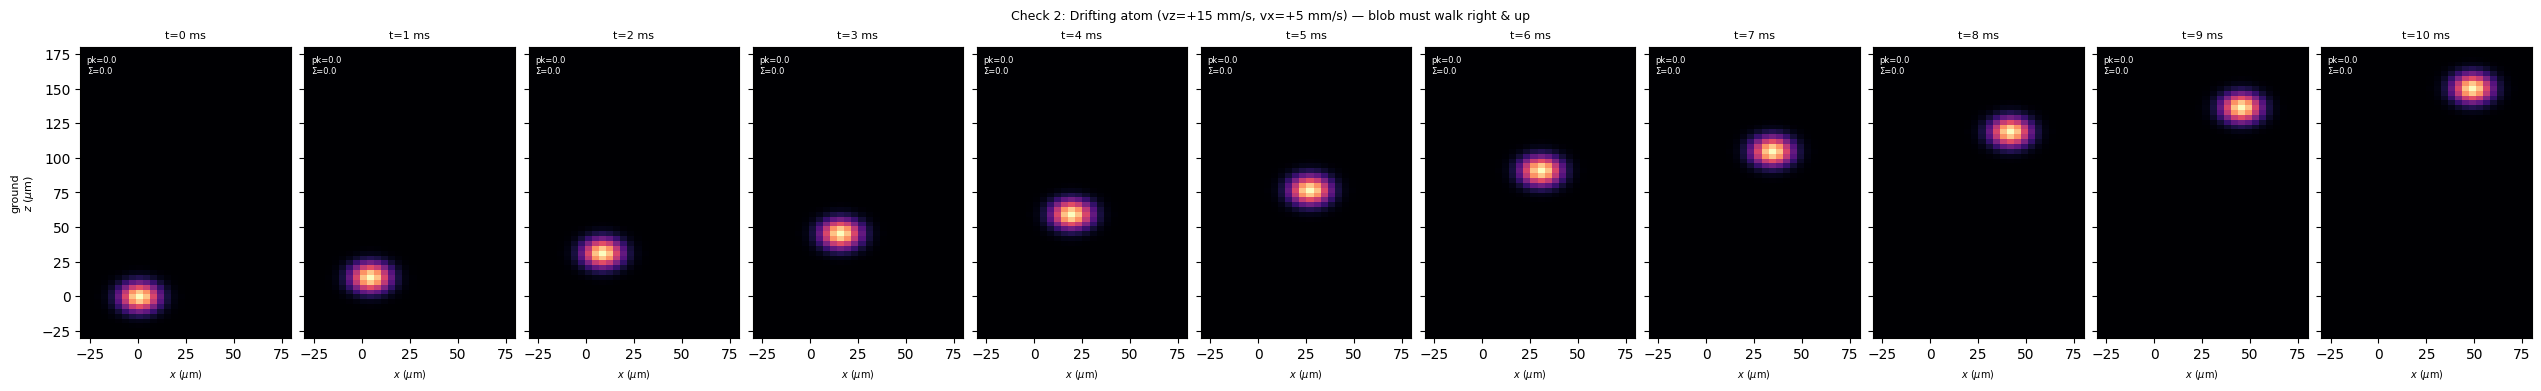

In [4]:
VZ =  15e-3   # m/s  → +150 µm over 10 ms
VX =   5e-3   # m/s  → +50 µm  over 10 ms

atoms_2 = [{"px": 0.0, "pz": 0.0, "vx": VX, "vz": VZ}]
snap_g2, _ = collect_snapshots(atoms_2, SEQUENCE, desc="Check 2")

# Centroid tracking
def centroid_um(branches):
    if not len(branches): return None, None
    w = branches[:, 3]
    return (np.sum(branches[:, 0]*w)/w.sum())*1e6, (np.sum(branches[:, 1]*w)/w.sum())*1e6

print(f"{'Label':10s}  {'x_cen µm':>10s}  {'z_cen µm':>10s}  {'Δx err µm':>10s}  {'Δz err µm':>10s}")
for i, (label, sg) in enumerate(zip(LABELS, snap_g2)):
    xc, zc = centroid_um(sg)
    if xc is not None:
        ex, ez = VX*i*DT*1e6, VZ*i*DT*1e6
        print(f"{label:10s}  {xc:+10.2f}  {zc:+10.2f}  {xc-ex:+10.4f}  {zc-ez:+10.4f}")

fig2 = render_filmstrip(
    snap_g2, LABELS,
    f"Check 2: Drifting atom (vz=+{VZ*1e3:.0f} mm/s, vx=+{VX*1e3:.0f} mm/s) — "
    "blob must walk right & up",
)
plt.show()

## Check 3 — Thermal cloud at 1 µK

200 atoms drawn from:
- Gaussian position distribution with σ = 100 µm in all three axes
- Maxwell–Boltzmann velocity distribution at *T* = 1 µK

The cloud width in z must grow from ~100 µm towards ~140 µm over 10 ms
(σ(t) = √(σ₀² + (σᵥ t)²)).

σ_v per axis = 9.78 mm/s
Expected σ_z at t=10 ms: 140 µm  (1.40× initial 100 µm)
Pixel size: 44 µm  →  19×19 grid over ±420 µm


Check 3:   0%|          | 0/1000 [00:00<?, ?it/s]

Check 3:   9%|▊         | 87/1000 [00:00<00:01, 865.50it/s]

Check 3:  17%|█▋        | 174/1000 [00:00<00:01, 824.47it/s]

Check 3:  27%|██▋       | 269/1000 [00:00<00:00, 879.54it/s]

...

Check 3:  65%|██████▌   | 652/1000 [00:00<00:00, 856.73it/s]

Check 3:  76%|███████▌  | 757/1000 [00:00<00:00, 912.89it/s]

Check 3:  85%|████████▌ | 853/1000 [00:00<00:00, 926.19it/s]

Check 3:  95%|█████████▌| 953/1000 [00:01<00:00, 947.32it/s]


Label         σ_z µm
t=0 ms         101.1
t=1 ms         101.6
t=2 ms         103.1
t=3 ms         105.6
t=4 ms         108.9
t=5 ms         113.0
t=6 ms         117.8
t=7 ms         123.2
t=8 ms         129.1
t=9 ms         135.6
t=10 ms        142.4


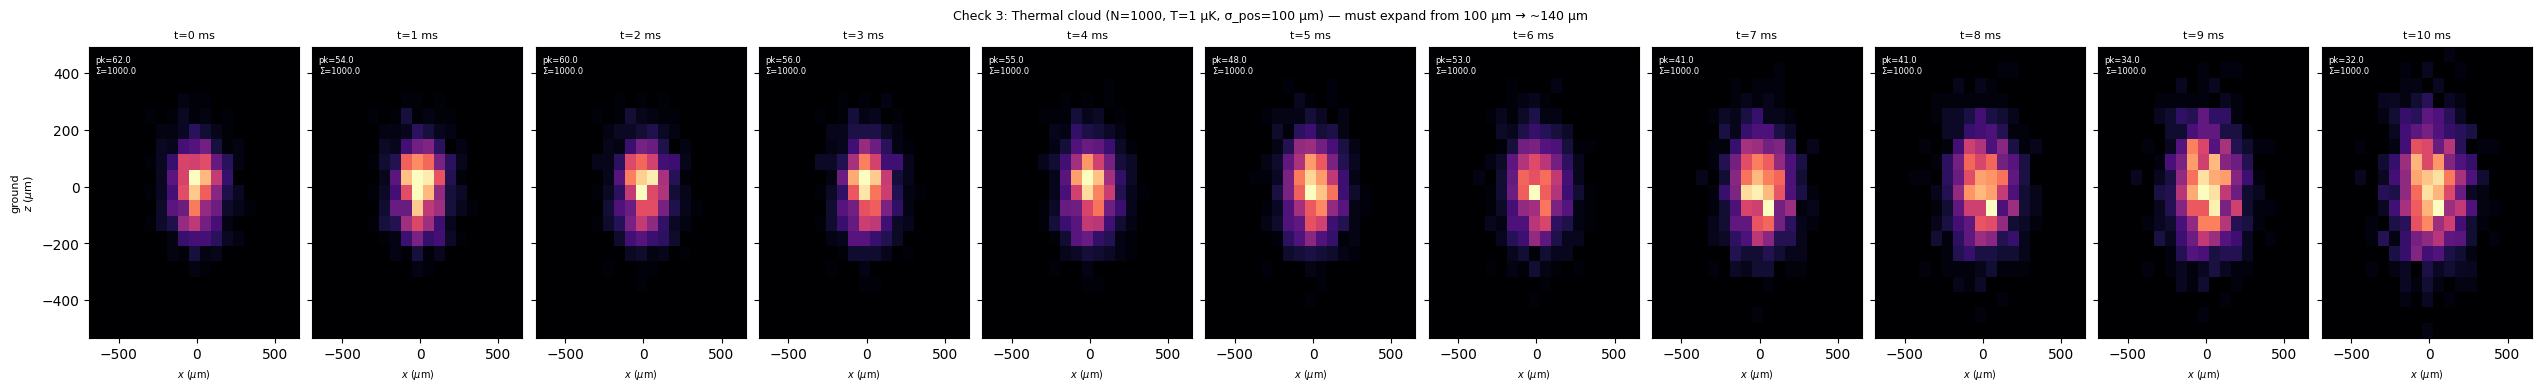

In [5]:
N_ATOMS = 1000
T_UK    = 1e-6          # 1 µK
SIG_POS = 100e-6        # 100 µm initial cloud radius

sigma_v = np.sqrt(constants.k * T_UK / sim.MASS_ATOM)
sig_final = np.sqrt(SIG_POS**2 + (sigma_v * N_STEPS * DT)**2)
print(f"σ_v per axis = {sigma_v*1e3:.2f} mm/s")
print(f"Expected σ_z at t=10 ms: {sig_final*1e6:.0f} µm  "
      f"({sig_final/SIG_POS:.2f}× initial {SIG_POS*1e6:.0f} µm)")

# Choose pixel size so that pixels at the 1.5σ ring contain ~5 atoms.
# Surface density at radius 1.5σ (integrating out the y axis):
#   n(1.5σ, 0) = N / (2π σ² ) * exp(-1.5²/2)
n_at_ring = N_ATOMS * np.exp(-1.5**2 / 2) / (2 * np.pi * sig_final**2)
target_per_pixel = 5
pixel_size = np.sqrt(target_per_pixel / n_at_ring)
image_half = 3.0 * sig_final          # image spans ±3σ
n_z = max(8, int(2 * image_half / pixel_size))
n_x = max(8, int(2 * image_half / pixel_size))
print(f"Pixel size: {pixel_size*1e6:.0f} µm  →  {n_x}×{n_z} grid "
      f"over ±{image_half*1e6:.0f} µm")

rng = np.random.default_rng(42)
pos = rng.normal(0.0, SIG_POS, (N_ATOMS, 3))
vel = rng.normal(0.0, sigma_v,  (N_ATOMS, 3))

atoms_3 = [
    {"px": pos[i,0], "py": pos[i,1], "pz": pos[i,2],
     "vx": vel[i,0], "vy": vel[i,1], "vz": vel[i,2]}
    for i in range(N_ATOMS)
]
snap_g3, _ = collect_snapshots(atoms_3, SEQUENCE, desc="Check 3")

# Report σ_z at each step
print(f"\n{'Label':10s}  {'σ_z µm':>8s}")
for label, sg in zip(LABELS, snap_g3):
    if len(sg):
        print(f"{label:10s}  {np.std(sg[:, 1])*1e6:8.1f}")

fig3 = render_filmstrip(
    snap_g3, LABELS,
    f"Check 3: Thermal cloud (N={N_ATOMS}, T=1 µK, σ_pos=100 µm) — "
    f"must expand from {SIG_POS*1e6:.0f} µm → ~{sig_final*1e6:.0f} µm",
    channel="ground", n_x=n_x, n_z=n_z,
    x_pad_min=0.5*pixel_size, z_pad_min=0.5*pixel_size,
    common_scale=False,
)
plt.show()